In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

import keras_tuner as kt

In [ ]:
# Load the dataset
df = pd.read_csv("aapl_cleaned.csv")

In [3]:
df.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
0,0,2015-03-16,27.758127,27.758127,27.296048,27.520423,143497200,0.011004,28.371493,26.537694,28.222433
1,1,2015-03-17,28.222433,28.284636,27.913639,27.969178,204092400,0.016727,28.362718,26.618291,28.540108
2,2,2015-03-18,28.540108,28.693394,28.073585,28.213541,261083600,0.011256,28.359940,26.718872,28.324614
3,3,2015-03-19,28.324614,28.713383,28.302399,28.602306,183238000,-0.007551,28.349388,26.815098,27.969172
4,4,2015-03-20,27.969172,28.524554,27.804778,28.491233,274780400,-0.012549,28.309401,26.897622,28.260189


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2465 entries, 0 to 2464
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2465 non-null   int64  
 1   Date          2465 non-null   str    
 2   Close         2465 non-null   float64
 3   High          2465 non-null   float64
 4   Low           2465 non-null   float64
 5   Open          2465 non-null   float64
 6   Volume        2465 non-null   int64  
 7   Daily_Return  2465 non-null   float64
 8   MA20          2465 non-null   float64
 9   MA50          2465 non-null   float64
 10  Target        2465 non-null   float64
dtypes: float64(8), int64(2), str(1)
memory usage: 212.0 KB


In [ ]:
# Remove the unwanted index column if it exists
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [6]:
df.tail()

,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
2460,2024-12-20,252.874359,253.381116,244.130223,246.465295,147495300,0.018816,242.209507,233.230407,253.649414
2461,2024-12-23,253.649414,254.026991,251.840961,253.152588,40858800,0.003065,243.471445,233.786257,256.560822
2462,2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700,0.011478,244.729906,234.325893,257.375580
2463,2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,245.920299,234.831204,253.967377
2464,2024-12-27,253.967377,257.057649,251.453440,256.193146,42355300,-0.013242,246.946741,235.309443,250.598907


In [ ]:
# Convert Date into datetime format
df["Date"] = pd.to_datetime(df["Date"])

# sorting dataset oldest to newest by date
df = df.sort_values("Date")

# Reset the row number
df = df.reset_index(drop=True)

# checking the first and last date of dataset
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

First date: 2015-03-16 00:00:00
Last date: 2024-12-27 00:00:00


In [8]:
df[["Date", "Close", "Target"]].head(10)

,Date,Close,Target
0,2015-03-16,27.758127,28.222433
1,2015-03-17,28.222433,28.540108
2,2015-03-18,28.540108,28.324614
3,2015-03-19,28.324614,27.969172
4,2015-03-20,27.969172,28.260189
5,2015-03-23,28.260189,28.144680
6,2015-03-24,28.144680,27.409342
7,2015-03-25,27.409342,27.600403
8,2015-03-26,27.600403,27.380465
9,2015-03-27,27.380465,28.073584


In [9]:
df[["Date", "Close", "Target"]].tail(10)

,Date,Close,Target
2455,2024-12-13,246.554779,249.446259
2456,2024-12-16,249.446259,251.870773
2457,2024-12-17,251.870773,246.475250
2458,2024-12-18,246.475250,248.204193
2459,2024-12-19,248.204193,252.874359
2460,2024-12-20,252.874359,253.649414
2461,2024-12-23,253.649414,256.560822
2462,2024-12-24,256.560822,257.375580
2463,2024-12-26,257.375580,253.967377
2464,2024-12-27,253.967377,250.598907


In [ ]:
#creating new target as the next day closing price
df["Target"] = df["Close"].shift(-1)

In [ ]:
# Remove the last row because it has no next-day target
df = df.dropna(subset=["Target"])

df = df.reset_index(drop=True)

In [12]:
df[["Date", "Close", "Target"]].tail(10)

,Date,Close,Target
2454,2024-12-12,246.385834,246.554779
2455,2024-12-13,246.554779,249.446259
2456,2024-12-16,249.446259,251.870773
2457,2024-12-17,251.870773,246.475250
2458,2024-12-18,246.475250,248.204193
2459,2024-12-19,248.204193,252.874359
2460,2024-12-20,252.874359,253.649414
2461,2024-12-23,253.649414,256.560822
2462,2024-12-24,256.560822,257.375580
2463,2024-12-26,257.375580,253.967377


In [13]:
df.isnull().sum()

Date            0
Close           0
High            0
Low             0
Open            0
Volume          0
Daily_Return    0
MA20            0
MA50            0
Target          0
dtype: int64

In [ ]:
# remove missing values and reset row numbers
df = df.dropna()

df = df.reset_index(drop=True)

print("Final dataset size:", df.shape)

Final dataset size: (2464, 10)


In [ ]:
# Selecting the features for next day prediction
feature_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "MA20",
    "MA50"
]

target_column = "Target"

In [ ]:
# Seperating the input and target feature
X = df[feature_columns]
y = df[[target_column]]

In [17]:
X.shape

(2464, 8)

In [18]:
y.shape

(2464, 1)

In [ ]:
# Using 70% of the earlier data for training
split_index = int(len(df) * 0.70)

# Earlier data as train and later data as test
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

In [20]:
print("Training days:", len(train_df))
print("Testing days:", len(test_df))

Training days: 1724
Testing days: 740


In [ ]:
print("Training period:")
print(train_df["Date"].min(),"to",train_df["Date"].max())

print("Testing period:")
print(test_df["Date"].min(),"to",test_df["Date"].max())

Training period:
2015-03-16 00:00:00 to 2022-01-14 00:00:00
Testing period:
2022-01-18 00:00:00 to 2024-12-26 00:00:00


In [ ]:
# Create separate scalers for features and target
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Fit the scalers only on the training data
feature_scaler.fit(train_df[feature_columns])
target_scaler.fit(train_df[[target_column]])

# Scale the feature and target values
scaled_features = feature_scaler.transform(df[feature_columns])
scaled_target = target_scaler.transform(df[[target_column]])

In [ ]:
# Creating empty lists to store LSTM sequences and targets
X = []
y = []

# Use the previous 60 trading days for each prediction
sequence_length = 60

# Create 60-day sequences for the LSTM model
for i in range(sequence_length - 1, len(df)):
    X.append(scaled_features[i-sequence_length+1:i+1])

    y.append(scaled_target[i, 0])

# Convert the lists into NumPy arrays
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2405, 60, 8)
y shape: (2405,)


In [ ]:

sequence_split = split_index - (sequence_length - 1)

X_train = X[:sequence_split]
X_test = X[sequence_split:]

y_train = y[:sequence_split]
y_test = y[sequence_split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1665, 60, 8)
X_test: (740, 60, 8)
y_train: (1665,)
y_test: (740,)


In [ ]:
# Creating the baseline LSTM model
base_model = Sequential()

# Add an LSTM layer with 64 units
base_model.add(LSTM(units=64,input_shape=(X_train.shape[1], X_train.shape[2])))

# Adding dropout to help reduce overfitting
base_model.add(Dropout(0.2))

# Adding one output neuron for the predicted closing price
base_model.add(Dense(1))

# Compile the model using Adam optimizer and MSE loss
base_model.compile(optimizer=Adam(learning_rate=0.001),loss='mse')

c:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train the baseline LSTM model
history = base_model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    # Keep the time order of the stock data
    shuffle=False,
    verbose=1
)

Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0035 - val_loss: 0.0029
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 3/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 4/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 5/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 6/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 7/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 8/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - val_loss: 9.6246e-04
Epoch 9/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.9269e-04 - val_loss: 0.0020
Epoch 10/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 11/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.6346e-04 - val_loss: 0.0028
Epoch 12/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

In [ ]:
# Predict the next-day closing prices for the test data
predictions = base_model.predict(X_test)

# Convert predicted values back to the original price scale
predictions_actual = target_scaler.inverse_transform(predictions)

# Convert actual test values back to the original price scale
y_test_actual = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
# Calculate the model evaluation metrics
mae = mean_absolute_error(y_test_actual,predictions_actual)

rmse = np.sqrt(mean_squared_error(y_test_actual,predictions_actual))

r2 = r2_score(y_test_actual,predictions_actual)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² :", round(r2, 4))

MAE : 5.06
RMSE: 6.03
R² : 0.958


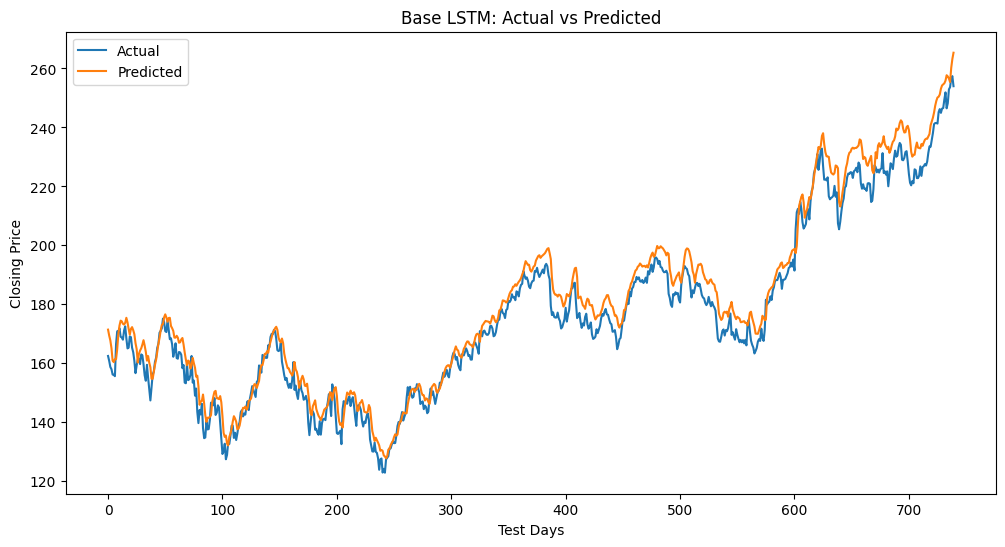

In [ ]:
# Compare the actual and predicted closing prices
plt.figure(figsize=(12,6))

plt.plot(y_test_actual,label="Actual")

plt.plot(predictions_actual,label="Predicted")

plt.title("Base LSTM: Actual vs Predicted")
plt.xlabel("Test Days")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

In [ ]:
# Hyperparameter tuning

# Create a function for LSTM hyperparameter tuning
def build_model(hp):

    model = Sequential()
    # Test different numbers of LSTM units
    units = hp.Int(
        'units',
        min_value=32,
        max_value=128,
        step=32
    )
    # Test different dropout values
    dropout = hp.Float(
        'dropout',
        min_value=0.1,
        max_value=0.5,
        step=0.1
    )
    # Test different learning rates
    learning_rate = hp.Choice(
        'learning_rate',
        values=[0.001,0.0005,0.0001]
    )
    # Add an LSTM layer using the selected number of units
    model.add(
        LSTM(
            units=units,
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )
    # Add the selected dropout value
    model.add(Dropout(dropout))
    # Add the output layer
    model.add(Dense(1))
    # Create Adam optimizer using the selected learning rate
    optimizer = Adam(
        learning_rate=learning_rate
    )
    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss='mse'
    )

    return model

In [ ]:
# Use Random Search to find better LSTM settings
tuner = kt.RandomSearch(
    build_model,
    # Select the model with the lowest validation loss
    objective='val_loss',
    # Test 10 different parameter combinations
    max_trials=10,
    overwrite=True,
    directory='C:/LSTM_Tuning',
    project_name='StockPrediction'
)

c:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Start searching for the best hyperparameters
tuner.search(
    X_train,
    y_train,
    epochs=50,
    # Use 20% of training data for validation
    validation_split=0.2,
    batch_size=32,
    # Do not shuffle time-series data
    shuffle=False,
    verbose=1
)

Trial 10 Complete [00h 00m 53s]
val_loss: 0.0010590365855023265

Best val_loss So Far: 0.0002925430017057806
Total elapsed time: 00h 09m 43s


In [ ]:
# Get the best hyperparameters found by Random Search
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Units:", best_hp.get('units'))
print("Best Dropout:", best_hp.get('dropout'))
print("Best Learning Rate:",best_hp.get('learning_rate'))

# Build the LSTM model using the best settings
hyper_model = tuner.hypermodel.build(best_hp)

# Train the tuned LSTM model
history = hyper_model.fit(
    X_train,
    y_train,
    epochs=60,
    validation_split=0.2,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Best Units: 96
Best Dropout: 0.30000000000000004
Best Learning Rate: 0.001
Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0026 - val_loss: 0.0014
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0014 - val_loss: 0.0080
Epoch 3/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 7.7233e-04 - val_loss: 7.8171e-04
Epoch 4/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 8.1891e-04 - val_loss: 0.0011
Epoch 5/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 6.4181e-04 - val_loss: 0.0013
Epoch 6/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 5.0172e-04 - val_loss: 0.0016
Epoch 7/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 6.9517e-04 - val_loss: 0.0031
Epoch 8/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0012 - val_loss: 6.1563e-04
Epoch 9/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0011 - val_loss: 9.8577e-04
Epoch 10/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.6704e-04 - val_loss: 7.0315e-04
Epoch 11/60
42/42 ━━━━━━━━━━━━━━━━

In [ ]:
# Make predictions using the tuned LSTM model
predictions = hyper_model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
# Convert predictions back to the original price scale
predictions_actual = target_scaler.inverse_transform(predictions)

# Convert actual values back to the original price scale
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

In [44]:
mae = mean_absolute_error(y_test_actual,predictions_actual)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))

r2 = r2_score(y_test_actual,predictions_actual)

print("Tuned LSTM Results")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² :", round(r2, 4))

Tuned LSTM Results
MAE : 6.72
RMSE: 7.44
R² : 0.936


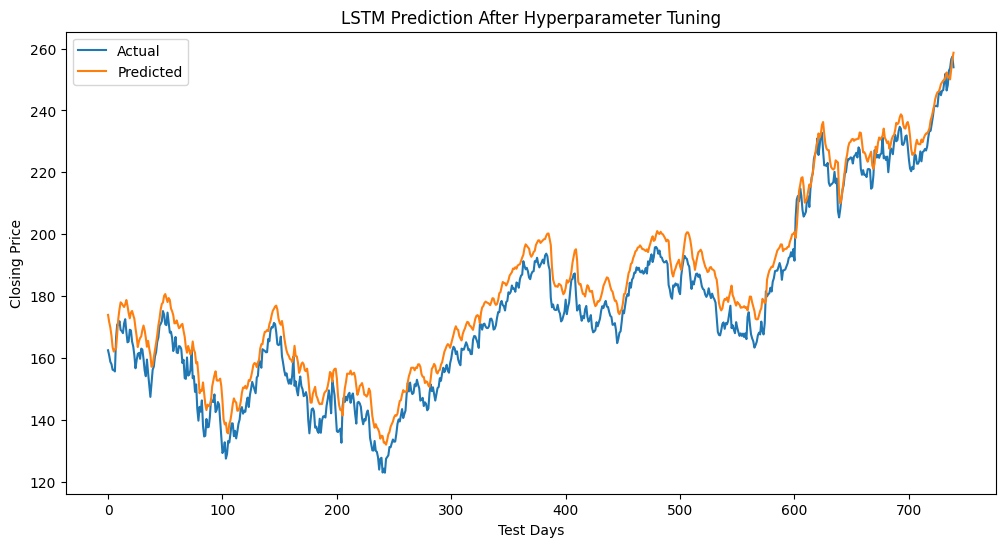

In [ ]:
# Compare actual prices with tuned LSTM predictions
plt.figure(figsize=(12,6))

plt.plot(y_test_actual,label="Actual")

plt.plot(predictions_actual,label="Predicted")

plt.title("LSTM Prediction After Hyperparameter Tuning")

plt.xlabel("Test Days")
plt.ylabel("Closing Price")
plt.legend()

plt.show()